# Strudel Corpus Analysis

Exploratory analysis of **855+ real Strudel patterns** mined from the song
repositories vendored under `corpus/sources/` (git submodules). The goal is to
measure **what elements people actually use** — synths, samples, drum machines,
transformations, mini-notation features — so that synthetic training-data
generation can be *weighted by reality* instead of uniform-random.

This notebook is self-contained: run top to bottom. It only reads the corpus;
it writes nothing except a few figures to `analysis/out/`.

**Sections**
1. Setup
2. Load the corpus
3. Corpus overview — sources & sizes
4. Sound sources — synths, drums, samples
5. Transformations & functions — the full taxonomy
6. Mini-notation features
7. Pattern complexity
8. Element transitions — what follows what
9. Export results as JSON
10. Takeaways for data generation

## 1. Setup

In [1]:
%matplotlib inline
import os, re, json, hashlib, collections
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.figsize": (9, 5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "axes.axisbelow": True,
})
PALETTE = ["#4C72B0", "#55A868", "#C44E52", "#8172B3", "#CCB974", "#64B5CD", "#937860", "#DA8BC3"]

# locate corpus/sources by walking up from the working dir
root = Path.cwd()
for _ in range(6):
    if (root / "corpus" / "sources").exists():
        break
    root = root.parent
CORPUS = root / "corpus" / "sources"
OUT = root / "analysis" / "out"; OUT.mkdir(parents=True, exist_ok=True)
print("corpus:", CORPUS)
assert CORPUS.exists(), "corpus/sources not found — run `git submodule update --init`"


corpus: /Users/henrik/Documents/Informatik/Master/restrudel/.claude/worktrees/analysis-notebook/corpus/sources


## 2. Load the corpus

A *pattern snippet* is extracted from three kinds of files, keeping only text
that looks like a **played** pattern (not library/build code):

- **`.mjs/.js`** — exported template-literal tunes (`export const x = \`...\``)
  and whole pattern files.
- **`.md/.mdx`** — fenced code blocks from the docs.

Snippets are de-duplicated across forks by normalized hash.

In [2]:
EXTS = (".js", ".mjs", ".mdx", ".md", ".txt")
PLAY_IDIOM = re.compile(r"(\$:|setcps?\(|setcpm\(|\bstack\s*\(|\bnote\s*\(|\bsound\s*\(|\.s\s*\(|\bs\s*\(\s*[\"'`])")
SKIP_PATH  = re.compile(r"(node_modules|/dist/|/build/|\.test\.|/krill|/parser|packages/.*/src/)", re.I)

def extract_snippets(path, text):
    ext = os.path.splitext(path)[1].lower()
    found = []
    if ext in (".mjs", ".js"):
        found += re.findall(r"=\s*`(.*?)`", text, re.S)
    if ext in (".mdx", ".md"):
        found += re.findall(r"```[a-zA-Z]*\n(.*?)```", text, re.S)
    if not found and ext in (".js", ".mjs", ".txt"):
        found.append(text)
    return [s for s in found if PLAY_IDIOM.search(s) and 15 < len(s) < 20000]

rows, seen = [], set()
for dirpath, _, files in os.walk(CORPUS):
    if "/.git" in dirpath: continue
    for fn in files:
        if not fn.endswith(EXTS): continue
        p = os.path.join(dirpath, fn)
        rel = os.path.relpath(p, CORPUS)
        if SKIP_PATH.search("/" + rel): continue
        try: text = open(p, encoding="utf-8", errors="ignore").read()
        except Exception: continue
        source = rel.split(os.sep)[0]
        for snip in extract_snippets(p, text):
            h = hashlib.md5(re.sub(r"\s+", "", snip).encode()).hexdigest()
            if h in seen: continue
            seen.add(h)
            rows.append({"source": source, "path": rel, "code": snip,
                         "chars": len(snip), "lines": snip.count(chr(10)) + 1})

patterns = pd.DataFrame(rows)
print(f"{len(patterns)} unique pattern snippets from {patterns.source.nunique()} sources")
patterns[["source", "path", "chars", "lines"]].head()

855 unique pattern snippets from 8 sources


,source,path,chars,lines
0,strudel-sampler-mixes,strudel-sampler-mixes/README.md,37,2
1,strudel-sampler-mixes,strudel-sampler-mixes/README.md,67,6
2,strudel-sampler-mixes,strudel-sampler-mixes/README.md,109,6
3,strudel-sampler-mixes,strudel-sampler-mixes/README.md,42,2
4,strudel-sampler-mixes,strudel-sampler-mixes/README.md,154,5


## 3. Corpus overview — where do patterns come from?

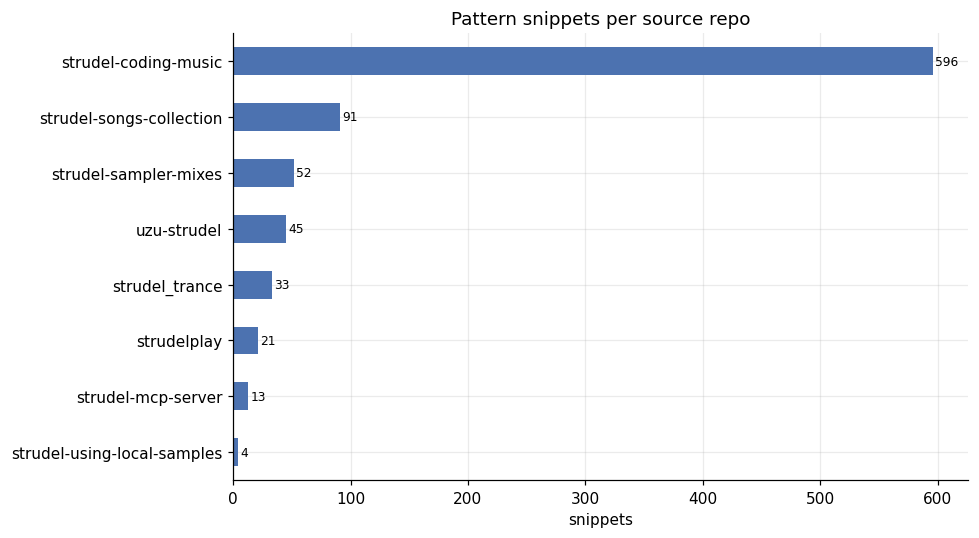

In [3]:
by_source = patterns.source.value_counts()
ax = by_source.sort_values().plot.barh(color=PALETTE[0])
ax.set_title("Pattern snippets per source repo"); ax.set_xlabel("snippets")
for i, v in enumerate(by_source.sort_values()):
    ax.text(v + 2, i, str(v), va="center", fontsize=8)
plt.tight_layout(); plt.savefig(OUT / "snippets_per_source.png"); plt.show()

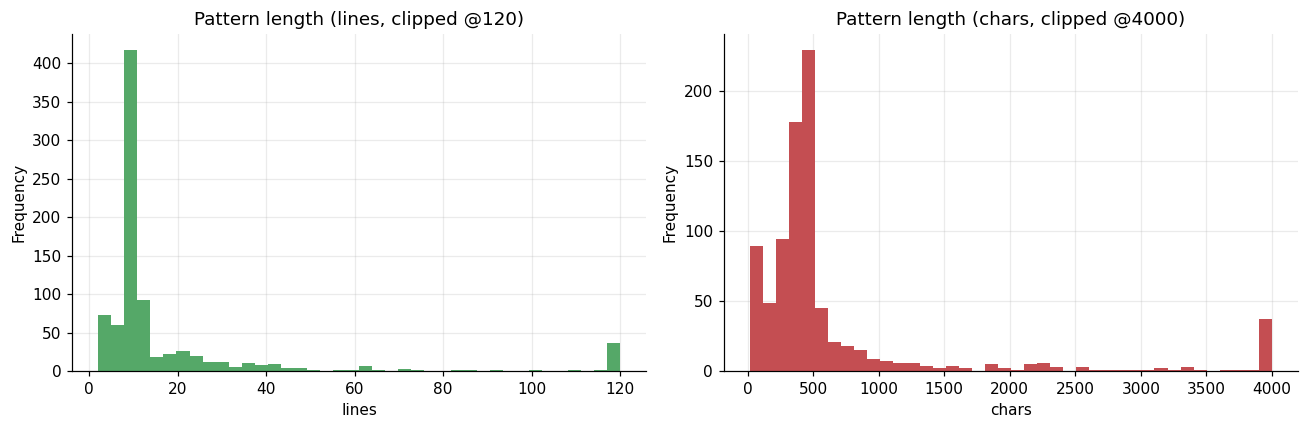

,chars,lines
count,855.0,855.0
mean,844.8,24.4
std,1734.8,56.4
min,17.0,2.0
25%,314.0,9.0
50%,417.0,10.0
75%,517.5,13.0
max,16413.0,506.0


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
patterns.lines.clip(upper=120).plot.hist(bins=40, ax=ax[0], color=PALETTE[1])
ax[0].set_title("Pattern length (lines, clipped @120)"); ax[0].set_xlabel("lines")
patterns.chars.clip(upper=4000).plot.hist(bins=40, ax=ax[1], color=PALETTE[2])
ax[1].set_title("Pattern length (chars, clipped @4000)"); ax[1].set_xlabel("chars")
plt.tight_layout(); plt.show()
patterns[["chars", "lines"]].describe().round(1)

## 4. Sound sources — synths, drums, samples

Strudel sounds come from `s("...")` / `sound("...")` (and `.s(...)`). The string
is mini-notation, so we tokenize it and strip operators / sample indices. Each
sound name is classified:

| category | examples |
|---|---|
| **waveform-synth** | sawtooth, square, triangle, sine, supersaw |
| **noise** | white, pink, brown |
| **soundfont (gm)** | gm_electric_bass_finger, gm_lead_… |
| **zzfx-synth** | z_sawtooth, z_… |
| **drum-sample** | bd, sd, hh, cp, oh, … |
| **other-sample** | everything else (named sample banks) |

In [5]:
WAVEFORMS = {"sine","sawtooth","saw","square","triangle","pulse","supersaw"}
NOISE = {"white","pink","brown","crackle","noise"}
DRUMS = {"bd","sd","sn","hh","oh","ch","rim","cp","cr","rd","lt","mt","ht","perc",
         "tom","clap","kick","snare","hat","ride","crash","click","misc"}
def classify(n):
    n = n.lower()
    if n in WAVEFORMS: return "waveform-synth"
    if n in NOISE: return "noise"
    if n.startswith("gm_"): return "soundfont(gm)"
    if n.startswith("z_"): return "zzfx-synth"
    if n in DRUMS: return "drum-sample"
    return "other-sample"

SOUND_CALL = re.compile(r"""(?:\bsound|\.?\bs)\s*\(\s*["'`]([^"'`]*)["'`]""", re.S)
BANK_CALL  = re.compile(r"""\.bank\s*\(\s*["'`]([^"'`]+)["'`]""")
TOKEN = re.compile(r"[A-Za-z_][A-Za-z0-9_.]*")
def sound_tokens(arg):
    out = []
    for tok in TOKEN.findall(arg):
        base = tok.split(":")[0].split(".")[0]
        if base and base != "_" and not base.isdigit():
            out.append(base)
    return out

sound_total = collections.Counter(); sound_snip = collections.Counter()
bank_total = collections.Counter(); cat_total = collections.Counter()
for code_ in patterns.code:
    local = collections.Counter()
    for arg in SOUND_CALL.findall(code_):
        for s in sound_tokens(arg): local[s] += 1
    for s, c in local.items():
        sound_total[s] += c; sound_snip[s] += 1; cat_total[classify(s)] += c
    bank_total.update(b.lower() for b in BANK_CALL.findall(code_))

sounds = pd.DataFrame([(s, c, sound_snip[s], classify(s)) for s, c in sound_total.items()],
                      columns=["sound","occurrences","patterns","category"]
                     ).sort_values("occurrences", ascending=False).reset_index(drop=True)
print(f"{len(sounds)} unique sounds")
sounds.head(15)

178 unique sounds


,sound,occurrences,patterns,category
0,bd,441,171,drum-sample
1,sd,236,102,drum-sample
2,hh,224,115,drum-sample
3,sawtooth,179,68,waveform-synth
4,cp,124,54,drum-sample
5,square,40,25,waveform-synth
6,triangle,35,26,waveform-synth
7,lt,34,8,drum-sample
8,oh,34,21,drum-sample
9,supersaw,32,13,waveform-synth


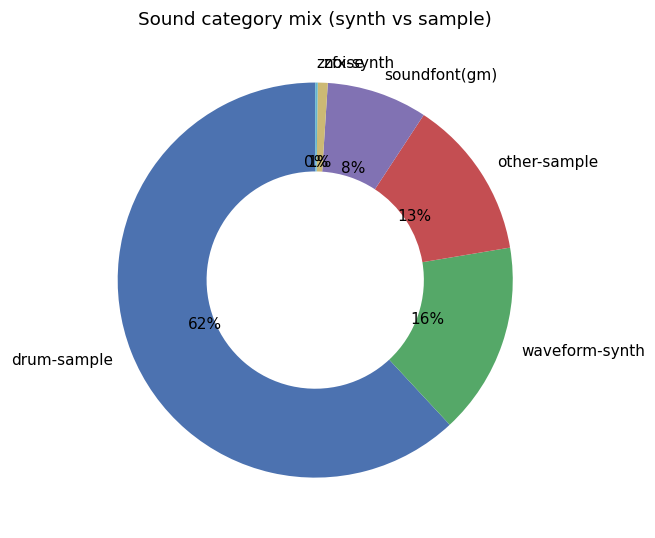

In [6]:
cats = pd.Series(cat_total).sort_values(ascending=False)
ax = cats.plot.pie(autopct="%1.0f%%", startangle=90, colors=PALETTE,
                   wedgeprops=dict(width=.45))
ax.set_ylabel(""); ax.set_title("Sound category mix (synth vs sample)")
plt.tight_layout(); plt.savefig(OUT / "category_mix.png"); plt.show()

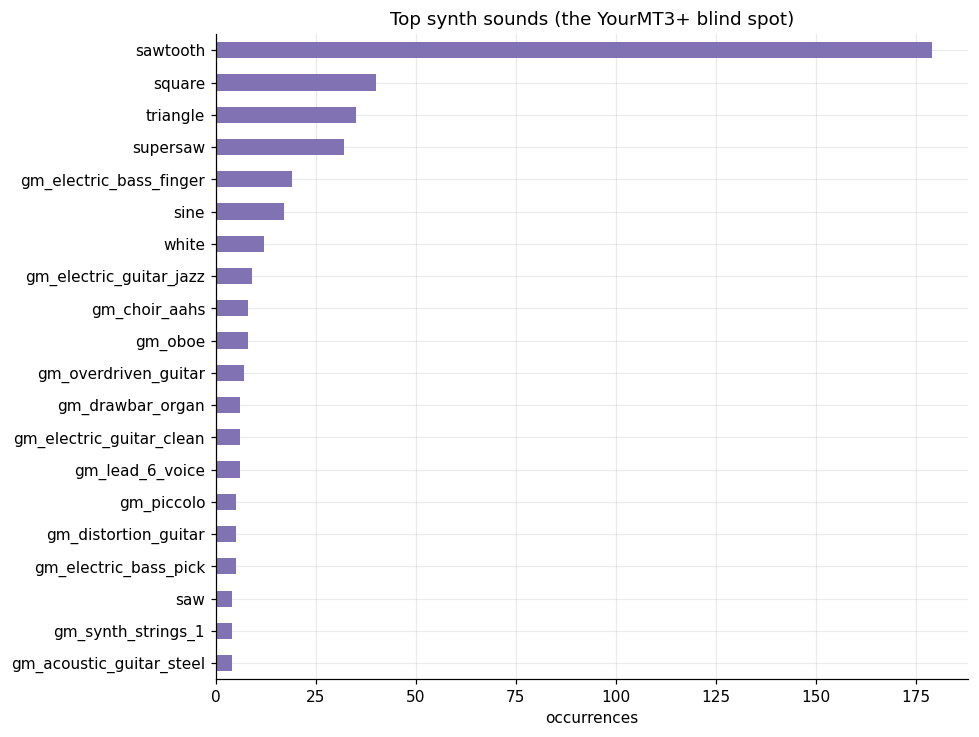

In [7]:
def topbar(df, label, value, title, n=20, color=PALETTE[0], fname=None):
    d = df.head(n).iloc[::-1]
    ax = d.plot.barh(x=label, y=value, color=color, legend=False,
                     figsize=(9, max(3, .34*len(d))))
    ax.set_title(title); ax.set_xlabel(value); ax.set_ylabel("")
    plt.tight_layout()
    if fname: plt.savefig(OUT / fname)
    plt.show()

synths = sounds[sounds.category.isin(["waveform-synth","soundfont(gm)","zzfx-synth","noise"])]
topbar(synths, "sound", "occurrences", "Top synth sounds (the YourMT3+ blind spot)",
       color=PALETTE[3], fname="top_synths.png")

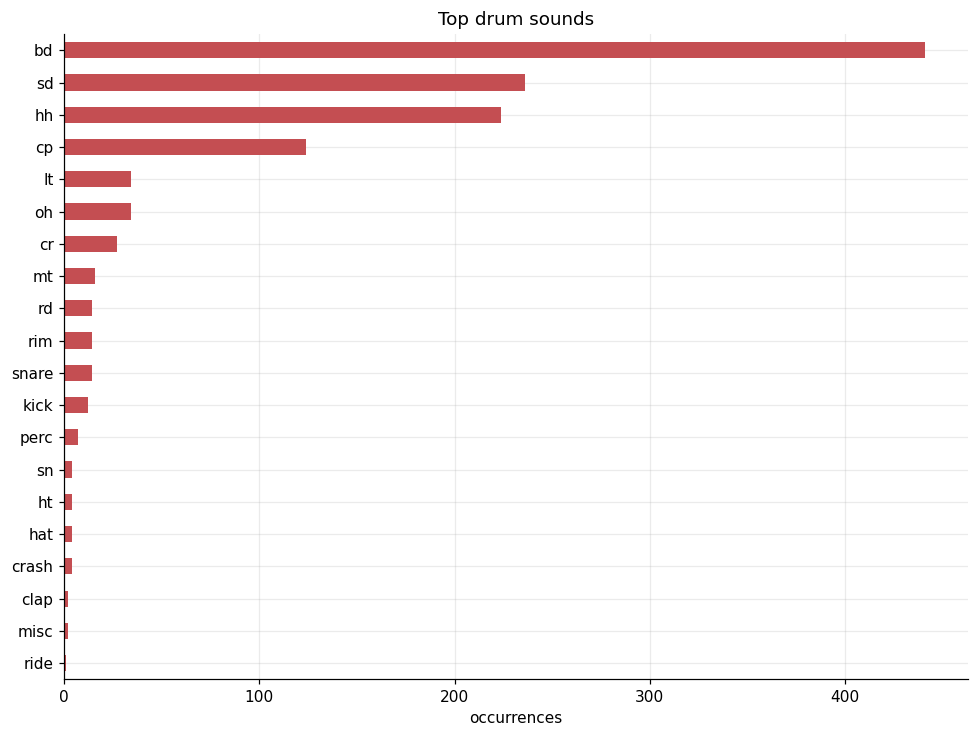

In [8]:
drums = sounds[sounds.category == "drum-sample"]
topbar(drums, "sound", "occurrences", "Top drum sounds", color=PALETTE[2])

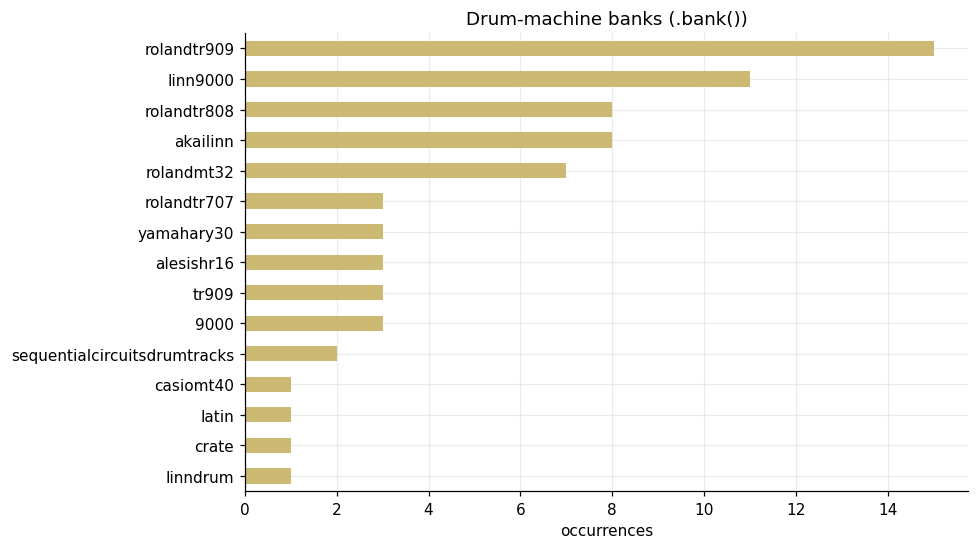

,bank,occurrences
0,rolandtr909,15
1,linn9000,11
2,rolandtr808,8
3,akailinn,8
4,rolandmt32,7
5,rolandtr707,3
6,yamahary30,3
7,alesishr16,3
8,tr909,3
9,9000,3


In [9]:
banks = pd.DataFrame(bank_total.most_common(), columns=["bank","occurrences"])
if len(banks):
    topbar(banks, "bank", "occurrences", "Drum-machine banks (.bank())",
           n=15, color=PALETTE[4], fname="banks.png")
banks.head(12)

**Reading the sounds.** Drums dominate by raw count (four-on-the-floor
`bd/sd/hh/cp`), but among *pitched* sounds **`sawtooth` is used far more than
anything else**, followed by `square`, `triangle`, `supersaw`, `sine`. These
subtractive-synth waveforms — shaped by filters/envelopes (next section) — are
exactly the timbres acoustic-sample-trained models like YourMT3+ never see.

## 5. Transformations & functions — the full taxonomy

Every `name(...)` call (source functions like `s(`/`note(` **and** chained
methods like `.fast(`/`.lpf(`) is counted and bucketed into a category. JS
keywords and helper noise are filtered out. This is the "statistics for all
element types" view: what each pattern is built from.

In [10]:
CATEGORIES = {
 "sound source": {"s","sound","note","n","freq"},
 "note / harmony": {"scale","voicing","chord","arp","arpWith","transpose","add","sub",
    "mul","div","toscale","rootNotes","anchor","mode","octave","ply"},
 "audio fx & params": {"gain","velocity","pan","lpf","cutoff","hpf","hcutoff","bpf",
    "bandf","lpq","resonance","hpq","bpq","room","roomsize","size","rsize","dry","orbit",
    "delay","delaytime","delayfeedback","delayfb","dt","fb","shape","distort","crush",
    "coarse","vowel","speed","accelerate","begin","end","loop","chop","striate","slice",
    "splice","attack","decay","sustain","release","adsr","hold","vib","vibmod","fm","fmh",
    "penv","pattack","prelease","lpenv","lpattack","lprelease","ftype","atk","dec","rel",
    "sus","clip","legato","gain"},
 "time & structure": {"fast","slow","hurry","rev","palindrome","iter","iterBack","stut",
    "echo","off","every","whenmod","chunk","chunkBack","struct","mask","euclid",
    "euclidLegato","euclidInv","euclidFull","segment","range","run","compress","zoom",
    "fastGap","inside","outside","ribbon","repeat","restart","early","late","swingBy",
    "swing","rolled","rotL","rotR","firstOf","lastOf","within","fit","ply"},
 "combinators / layering": {"stack","cat","seq","fastcat","slowcat","timeCat","polymeter",
    "polymeterSteps","jux","juxBy","superimpose","layer","overlay","append","fastAppend",
    "slowAppend","stackBy","squeeze"},
 "randomness / variation": {"rand","irand","perlin","choose","wchoose","chooseCycles",
    "randcat","wrandcat","shuffle","scramble","pickRestart","pick","someCycles",
    "someCyclesBy","sometimes","sometimesBy","often","rarely","almostAlways","almostNever",
    "always","never","degrade","undegrade","degradeBy","undegradeBy"},
 "signals / lfo": {"sine","cosine","saw","isaw","tri","square","time"},
 "meta / control": {"setcps","setcpm","cps","cpm","all","hush","color","pianoroll",
    "punchcard","scope","spectrum","fscope"},
}
LOOKUP = {fn: cat for cat, fns in CATEGORIES.items() for fn in fns}
JS_NOISE = {"function","register","if","for","while","return","const","let","var","map",
    "filter","forEach","withValue","console","log","Math","require","import","export",
    "async","await","Array","Object","String","Number","parseInt","parseFloat","push"}

CALL = re.compile(r"\b([A-Za-z_]\w*)\s*\(")
fn_snip = collections.Counter()   # # patterns using
fn_total = collections.Counter()  # raw occurrences
for code_ in patterns.code:
    names = [m for m in CALL.findall(code_) if m not in JS_NOISE]
    fn_total.update(names)
    fn_snip.update(set(names))

funcs = pd.DataFrame([(f, fn_total[f], fn_snip[f], LOOKUP.get(f, "other"))
                      for f in fn_total],
                     columns=["function","occurrences","patterns","category"]
                    ).sort_values("patterns", ascending=False).reset_index(drop=True)
print(f"{len(funcs)} distinct functions/elements")
funcs.head(25)

827 distinct functions/elements


,function,occurrences,patterns,category
0,s,1576,740,sound source
1,stack,744,630,combinators / layering
2,slow,811,580,time & structure
3,note,558,202,sound source
4,gain,827,169,audio fx & params
5,room,359,124,audio fx & params
6,lpf,347,101,audio fx & params
7,n,198,91,sound source
8,scale,158,89,note / harmony
9,add,187,87,note / harmony


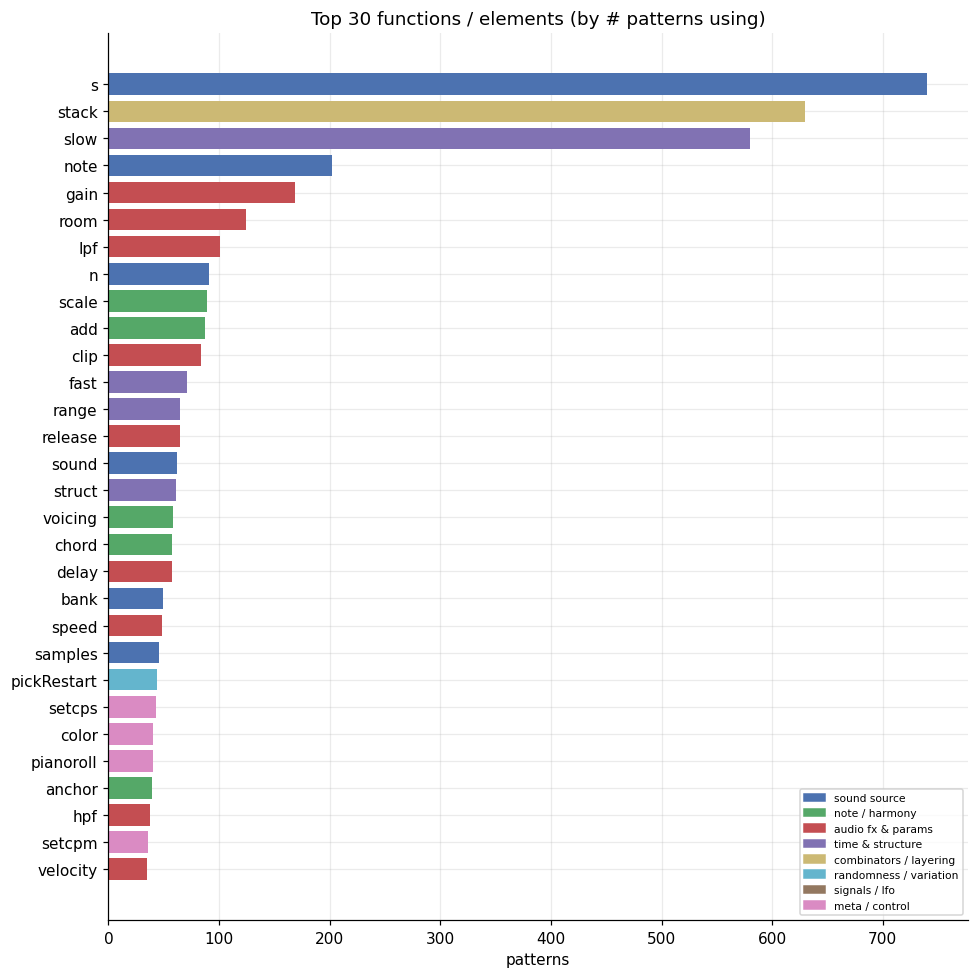

In [11]:
cat_color = {c: PALETTE[i % len(PALETTE)] for i, c in enumerate(
    list(CATEGORIES) + ["other"])}
top = funcs.head(30).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 9))
ax.barh(top.function, top.patterns, color=[cat_color[c] for c in top.category])
ax.set_title("Top 30 functions / elements (by # patterns using)"); ax.set_xlabel("patterns")
handles = [mpl.patches.Patch(color=cat_color[c], label=c) for c in CATEGORIES]
ax.legend(handles=handles, fontsize=7, loc="lower right")
plt.tight_layout(); plt.savefig(OUT / "top_functions.png"); plt.show()

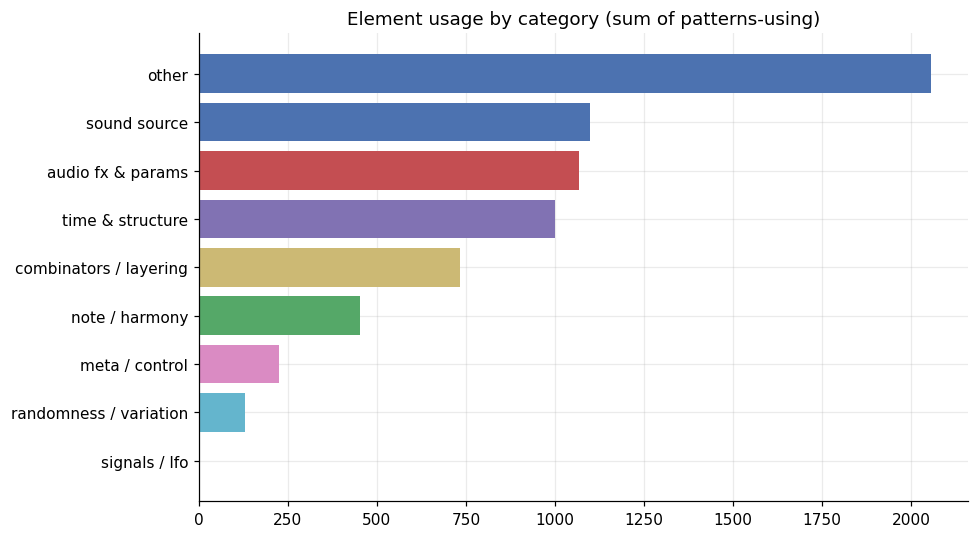

In [12]:
# how much is each CATEGORY used (sum of patterns-using across its functions)
cat_use = funcs.groupby("category").patterns.sum().sort_values()
fig, ax = plt.subplots()
ax.barh(cat_use.index, cat_use.values,
        color=[cat_color.get(c, "#999") for c in cat_use.index])
ax.set_title("Element usage by category (sum of patterns-using)"); ax.set_xlabel("")
plt.tight_layout(); plt.savefig(OUT / "category_usage.png"); plt.show()

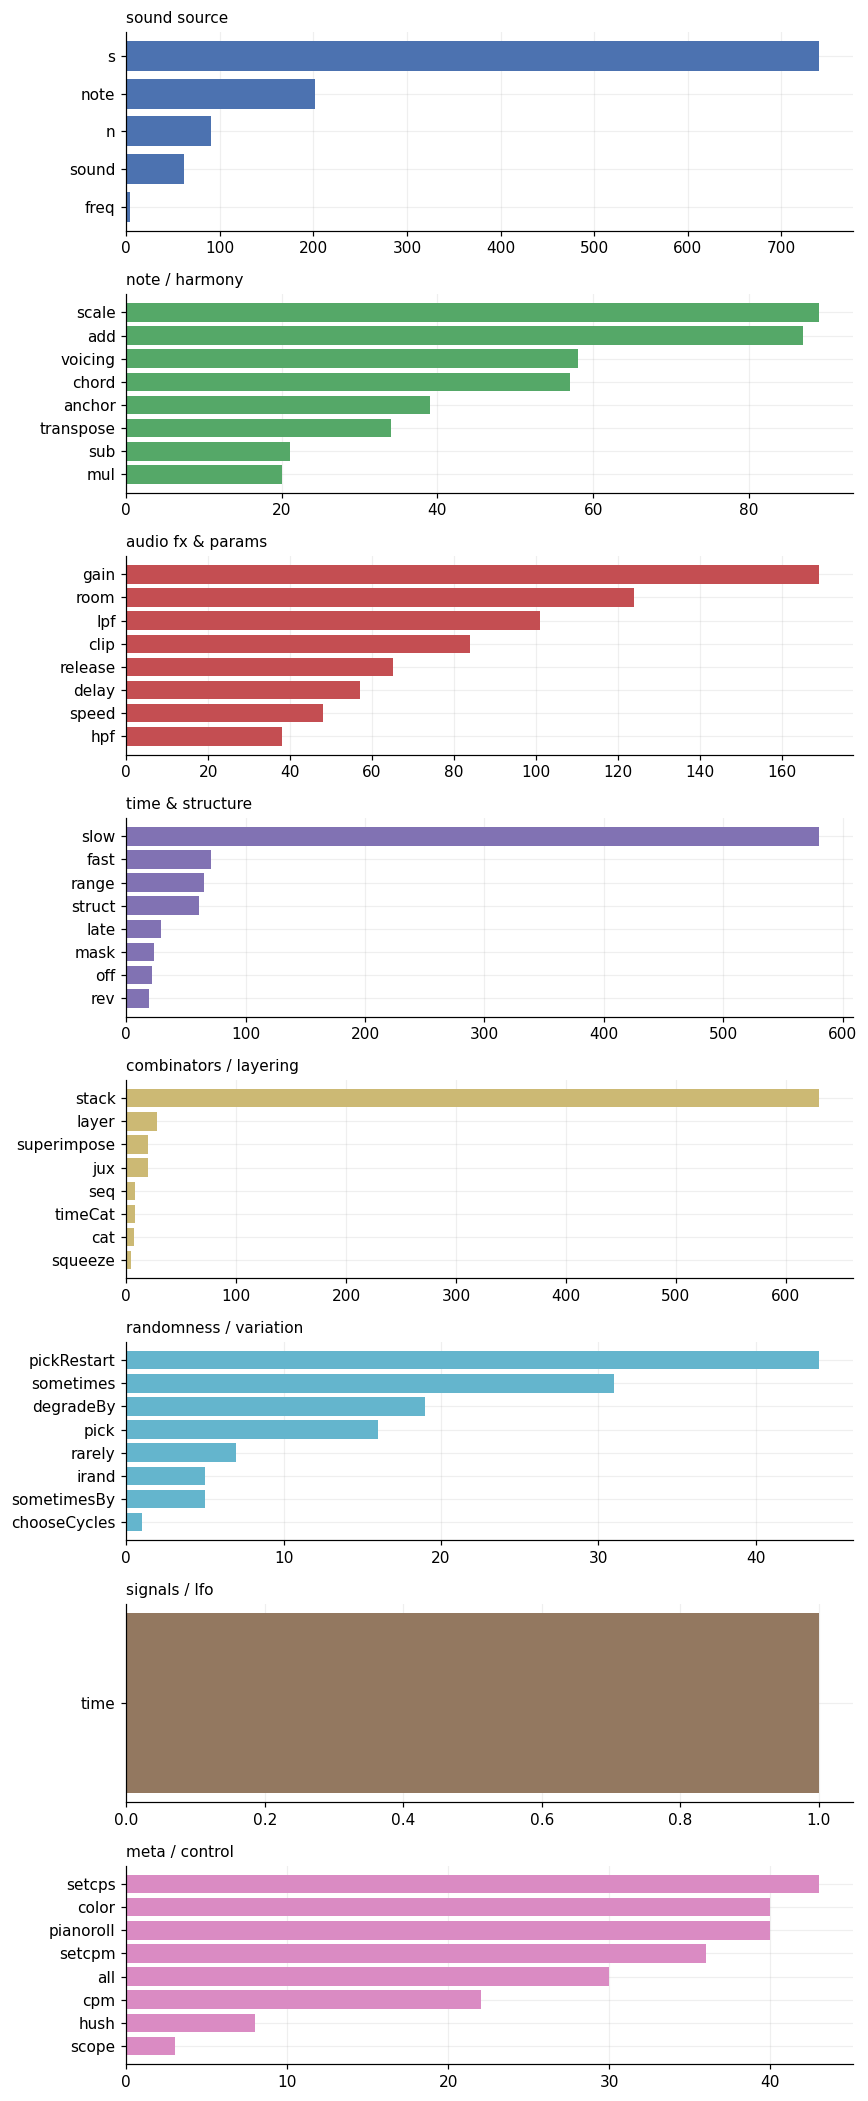

In [13]:
# top functions WITHIN each category
order = [c for c in CATEGORIES if (funcs.category == c).any()]
fig, axes = plt.subplots(len(order), 1, figsize=(8, 2.4*len(order)))
for ax, c in zip(axes, order):
    d = funcs[funcs.category == c].head(8).iloc[::-1]
    ax.barh(d.function, d.patterns, color=cat_color[c])
    ax.set_title(c, fontsize=10, loc="left"); ax.grid(alpha=.2)
plt.tight_layout(); plt.savefig(OUT / "per_category_functions.png"); plt.show()

**Reading the functions.** The dominant transformations are exactly a
subtractive-synth toolkit: filtering (`lpf`/`cutoff`), envelopes
(`release`/`attack`/`adsr`), space (`room`/`delay`), level (`gain`), and
structure (`struct`/`fast`/`slow`/`every`). For data generation these are both
the **params to randomize** and the **labels to emit** alongside notes.

## 6. Mini-notation features

Mini-notation is the string DSL inside `"..."`. We count how often each operator
appears across patterns — this tells us which rhythmic/structural constructs the
generator (and any MIDI→Strudel stage) must support.

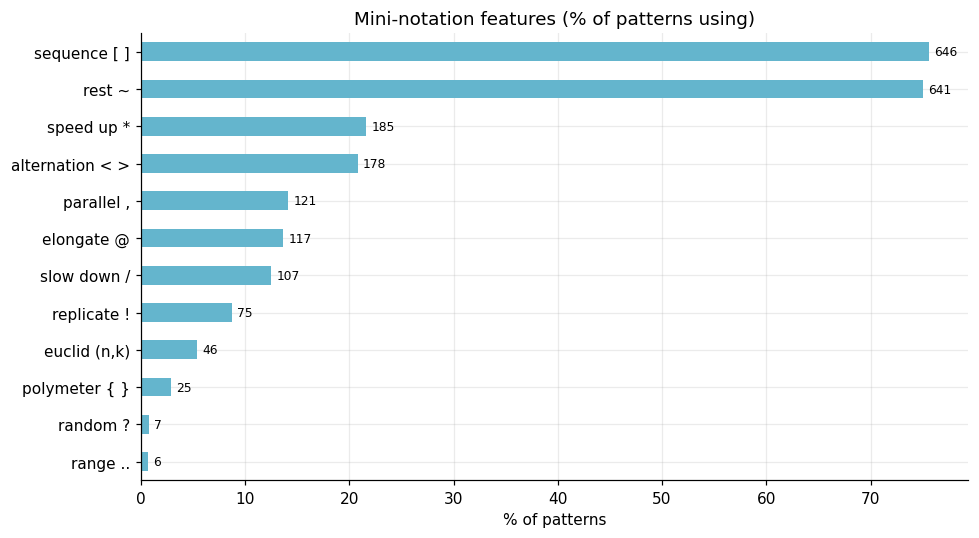

In [14]:
MINI = {
 "sequence [ ]":      r"\[",
 "alternation < >":   r"<",
 "polymeter { }":     r"\{",
 "euclid (n,k)":      r"\([0-9]+\s*,",
 "replicate !":       r"!",
 "elongate @":        r"@",
 "speed up *":        r"\*",
 "slow down /":       r"/",
 "rest ~":            r"~",
 "random ?":          r"\?",
 "range ..":          r"\.\.",
 "parallel ,":        r"[A-Za-z0-9\]]\s*,\s*[A-Za-z0-9\[]",
}
def strings_of(code_):
    return re.findall(r'"([^"]*)"', code_) + re.findall(r"`([^`]*)`", code_)
mini_snip = collections.Counter()
for code_ in patterns.code:
    blob = " ".join(strings_of(code_))
    for name, pat in MINI.items():
        if re.search(pat, blob): mini_snip[name] += 1
mini = (pd.Series(mini_snip).reindex(MINI.keys()).fillna(0).astype(int)
        .sort_values())
ax = (100 * mini / len(patterns)).plot.barh(color=PALETTE[5])
ax.set_title("Mini-notation features (% of patterns using)"); ax.set_xlabel("% of patterns")
for i, v in enumerate(mini):
    ax.text(100*v/len(patterns)+.5, i, f"{v}", va="center", fontsize=8)
plt.tight_layout(); plt.savefig(OUT / "mini_notation.png"); plt.show()

## 7. Pattern complexity

/var/folders/ct/gz2l61m13y595l77djnpfg480000gn/T/ipykernel_71755/3702726644.py:5: UserWarning: This pattern has match groups. To actually get the groups, use str.extract.
  patterns["has_tempo"] = patterns.code.str.contains(CPS)


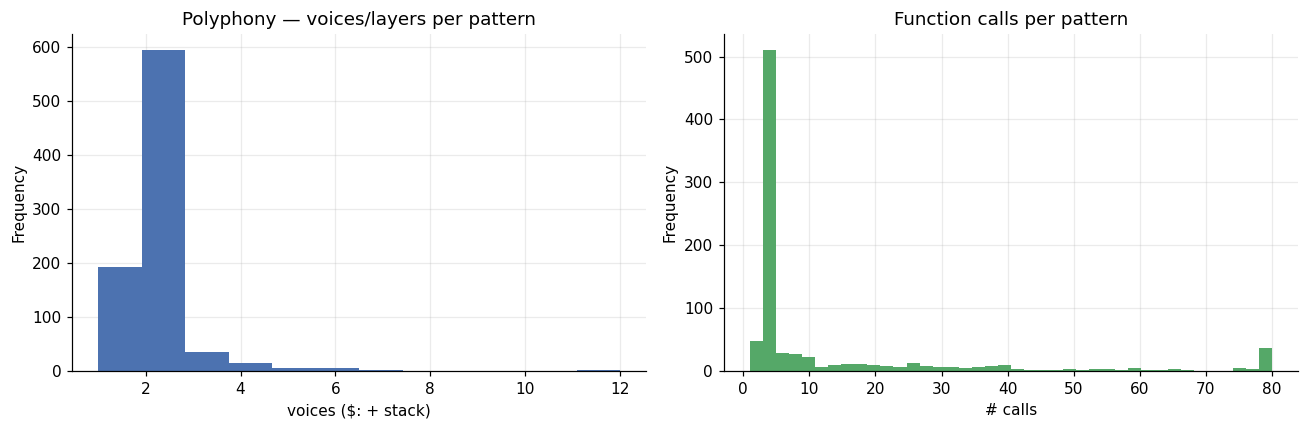

,n_voices,n_funcs
count,855.0,855.0
mean,2.0,16.1
std,1.1,33.6
min,1.0,1.0
25%,2.0,3.0
50%,2.0,3.0
75%,2.0,12.0
max,15.0,305.0


In [15]:
patterns["n_voices"] = patterns.code.str.count(r"\$:").clip(lower=1) + \
    patterns.code.apply(lambda c: c.count("stack("))
patterns["n_funcs"] = patterns.code.apply(lambda c: len(CALL.findall(c)))
CPS = re.compile(r"setcp[sm]\s*\(\s*([0-9.]+)")
patterns["has_tempo"] = patterns.code.str.contains(CPS)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
patterns.n_voices.clip(upper=12).plot.hist(bins=12, ax=ax[0], color=PALETTE[0])
ax[0].set_title("Polyphony — voices/layers per pattern"); ax[0].set_xlabel("voices ($: + stack)")
patterns.n_funcs.clip(upper=80).plot.hist(bins=40, ax=ax[1], color=PALETTE[1])
ax[1].set_title("Function calls per pattern"); ax[1].set_xlabel("# calls")
plt.tight_layout(); plt.show()
patterns[["n_voices","n_funcs"]].describe().round(1)

## 8. Element transitions — what follows what (method chains)

Strudel patterns are method chains: `note("..").s("..").lpf(..).room(..)`. We parse
each chain — handling nested calls, `stack(...)`, arrow functions and strings —
and measure, **for every element, which element(s) most commonly follow it**, at
**depth 1** (the immediate next call) and **depth 2** (the next two). This is a
Markov model `data_gen/` can sample to build realistic chains.

In [16]:
def _strip_strings(s):
    s = re.sub(r'"(?:[^"\\]|\\.)*"', '""', s)
    s = re.sub(r"'(?:[^'\\]|\\.)*'", "''", s)
    s = re.sub(r"`(?:[^`\\]|\\.)*`", "``", s)
    return s

def method_chains(code):
    """Return a list of chains; each chain is the ordered list of call names
    linked by '.' at one nesting level (e.g. ['s','gain','release'])."""
    s = _strip_strings(code); N = len(s); out = []; open_chain = {0: None}; depth = 0; i = 0
    def emit(d):
        c = open_chain.get(d)
        if c: out.append(c)
        open_chain[d] = None
    while i < N:
        c = s[i]
        if c == '(':
            depth += 1; open_chain[depth] = None; i += 1
        elif c == ')':
            emit(depth); depth = max(0, depth - 1); i += 1
        elif c == ',':
            emit(depth); i += 1
        elif c.isalpha() or c == '_':
            j = i
            while j < N and (s[j].isalnum() or s[j] == '_'): j += 1
            name = s[i:j]; k = j
            while k < N and s[k] in ' \t\n': k += 1
            if k < N and s[k] == '(':                      # it's a call
                p = i - 1
                while p >= 0 and s[p] in ' \t\n': p -= 1
                is_method = p >= 0 and s[p] == '.'         # chained vs head
                cur = open_chain.get(depth)
                if is_method and cur:
                    cur.append(name)
                else:
                    if cur: out.append(cur)
                    open_chain[depth] = [name]
            i = j
        else:
            i += 1
    for d in list(open_chain): emit(d)
    return [c for c in out if c]

all_chains = [ch for code in patterns.code for ch in method_chains(code)]
print(len(all_chains), "method chains;  avg length",
      round(sum(len(c) for c in all_chains) / len(all_chains), 2))

5447 method chains;  avg length 2.31


In [17]:
bigrams = collections.Counter()
trigrams = collections.Counter()
for ch in all_chains:
    for a, b in zip(ch, ch[1:]): bigrams[(a, b)] += 1
    for a, b, c in zip(ch, ch[1:], ch[2:]): trigrams[(a, b, c)] += 1

bi = pd.DataFrame([(a, b, n) for (a, b), n in bigrams.items()],
                  columns=["from", "to", "count"]).sort_values("count", ascending=False
                  ).reset_index(drop=True)
print(f"{len(bigrams)} distinct depth-1 transitions, {len(trigrams)} depth-2")
bi.head(15)

1657 distinct depth-1 transitions, 1852 depth-2


,from,to,count
0,s,slow,476
1,stack,s,470
2,s,gain,329
3,note,sound,174
4,sound,lpf,163
5,gain,release,107
6,lpf,gain,104
7,room,gain,90
8,lpf,room,85
9,note,s,81


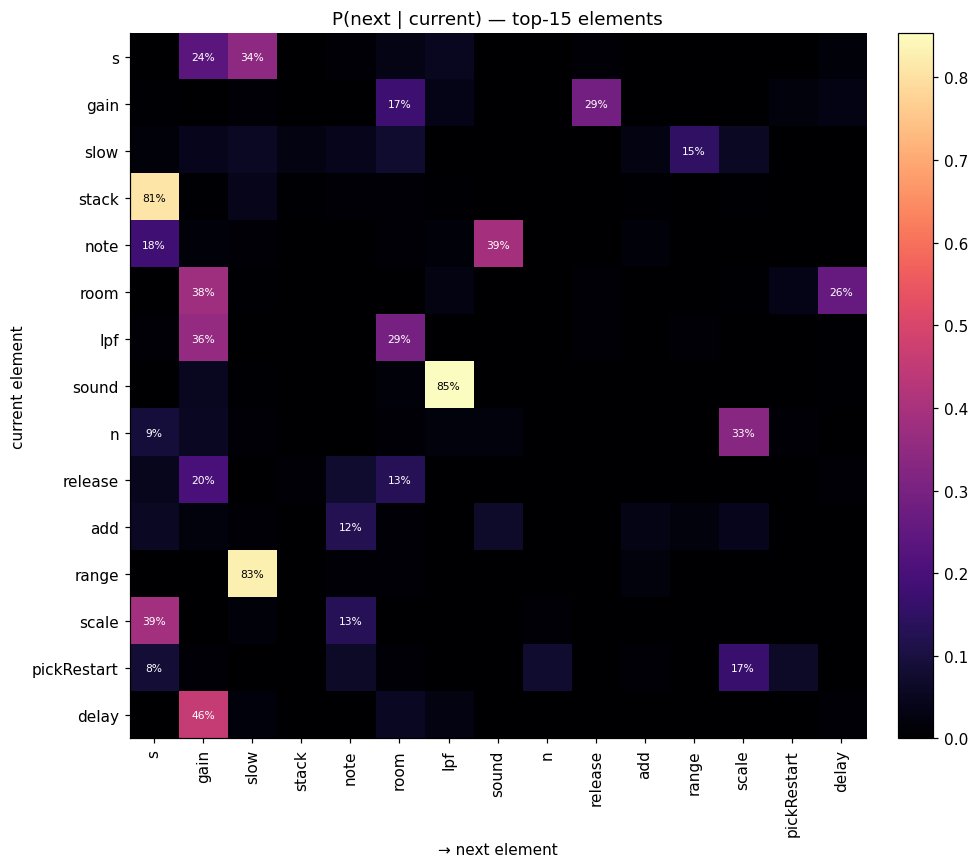

In [18]:
import numpy as np
TOPK = funcs.sort_values("occurrences", ascending=False).function.head(15).tolist()
from_tot = collections.Counter()
for (a, b), n in bigrams.items(): from_tot[a] += n
M = np.zeros((len(TOPK), len(TOPK)))
for i, a in enumerate(TOPK):
    for j, b in enumerate(TOPK):
        if from_tot[a]: M[i, j] = bigrams.get((a, b), 0) / from_tot[a]

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(M, cmap="magma", aspect="auto")
ax.set_xticks(range(len(TOPK))); ax.set_xticklabels(TOPK, rotation=90)
ax.set_yticks(range(len(TOPK))); ax.set_yticklabels(TOPK)
ax.set_xlabel("→ next element"); ax.set_ylabel("current element")
ax.set_title("P(next | current) — top-15 elements"); ax.grid(False)
fig.colorbar(im, fraction=0.046, pad=0.04)
for i in range(len(TOPK)):
    for j in range(len(TOPK)):
        if M[i, j] >= 0.08:
            ax.text(j, i, f"{M[i, j]:.0%}", ha="center", va="center",
                    color="w" if M[i, j] < 0.55 else "k", fontsize=7)
plt.tight_layout(); plt.savefig(OUT / "transition_heatmap.png"); plt.show()

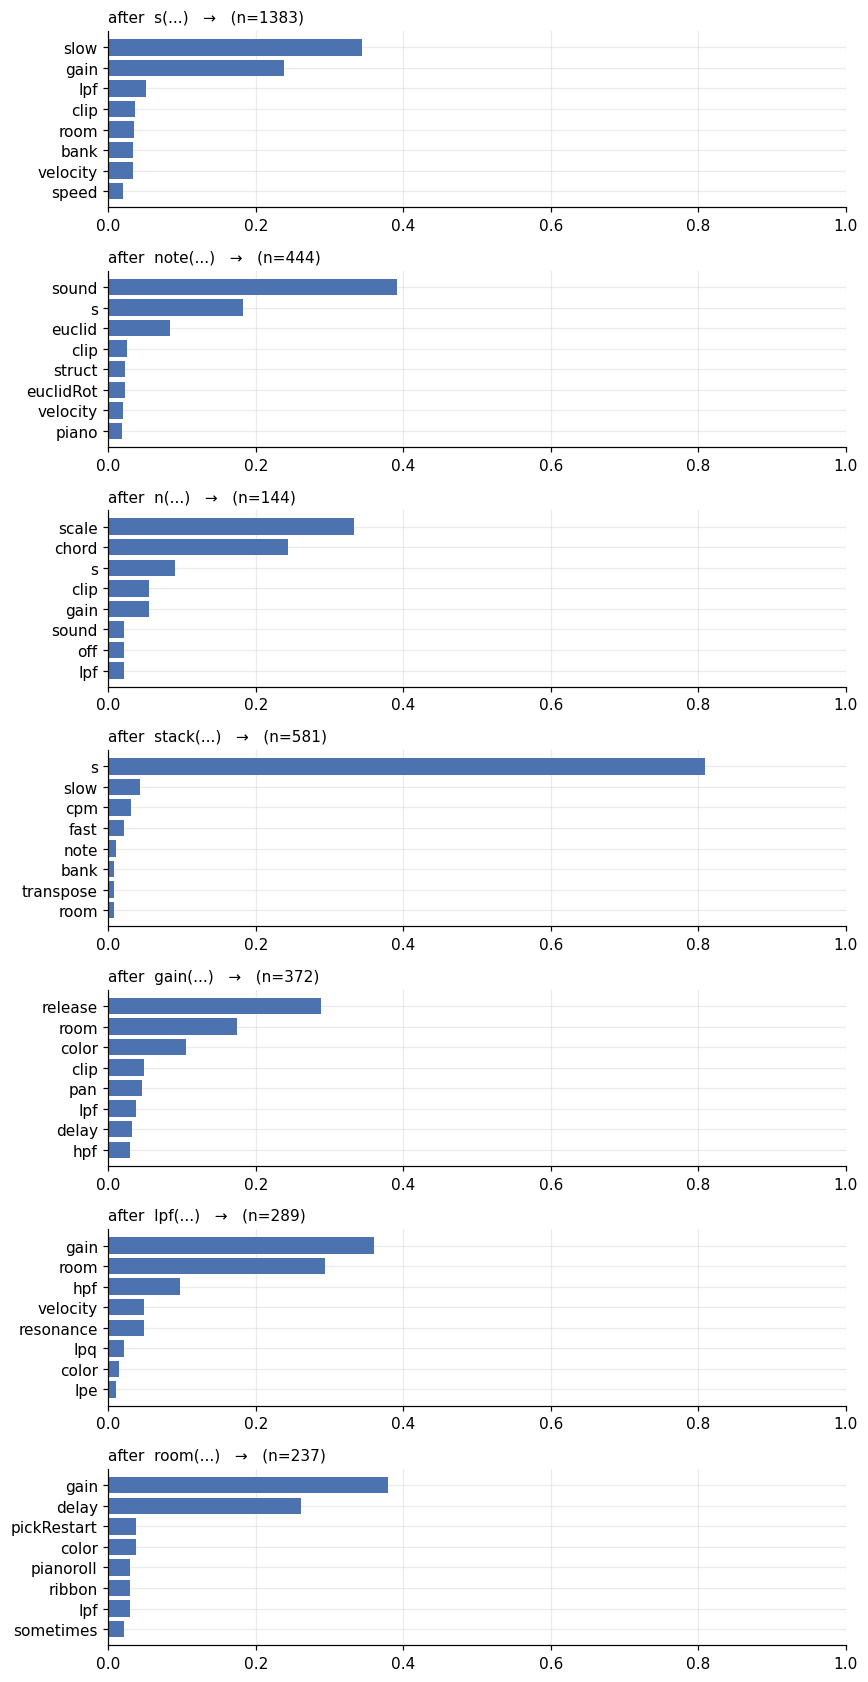

In [19]:
def successors(head, k=8):
    succ = collections.Counter()
    for ch in all_chains:
        for a, b in zip(ch, ch[1:]):
            if a == head: succ[b] += 1
    tot = sum(succ.values()) or 1
    return [(b, n, n / tot) for b, n in succ.most_common(k)], tot

heads = [h for h in ["s", "note", "n", "stack", "gain", "lpf", "room"]
         if (funcs.function == h).any()]
fig, axes = plt.subplots(len(heads), 1, figsize=(8, 2.2 * len(heads)))
for ax, h in zip(np.atleast_1d(axes), heads):
    rows, tot = successors(h); rows = rows[::-1]
    ax.barh([r[0] for r in rows], [r[2] for r in rows], color=PALETTE[0])
    ax.set_title(f"after  {h}(...)   →   (n={tot})", fontsize=10, loc="left")
    ax.set_xlim(0, 1)
plt.tight_layout(); plt.savefig(OUT / "top_successors.png"); plt.show()

**Reading the transitions.** The chains encode Strudel idioms: `n → scale/chord`
(melody), `note → s/sound` (assign an instrument), `s → gain/lpf/room` (level then
shape), `gain → release`, `lpf → room → delay` (filter into space). A generator can
walk this Markov model to emit chains that look hand-written.

## 9. Export results as JSON

Everything above is written to **`analysis/results/*.json`** in a **consistent
envelope** for reuse by `data_gen/`. Every file shares the same top-level keys
(`schema_version`, `generated_from`, `n_patterns`, `n_sources`) and carries
sampling `weight`/`prob` fields so generation can draw directly from the real
distributions. See `analysis/results/README.md` for the schema.

In [20]:
import json
RESULTS = root / "analysis" / "results"; RESULTS.mkdir(parents=True, exist_ok=True)
ENV = {"schema_version": 1, "generated_from": "notebooks/01_corpus_analysis.ipynb",
       "n_patterns": int(len(patterns)), "n_sources": int(patterns.source.nunique())}

def write_json(name, body):
    obj = dict(ENV); obj.update(body)
    path = RESULTS / f"{name}.json"
    path.write_text(json.dumps(obj, indent=2))
    return f"{name}.json ({path.stat().st_size:,} bytes)"

written = []
tot_s = int(sounds.occurrences.sum())
written.append(write_json("sounds", {"schema": "sounds.v1", "items": [
    {"name": r.sound, "occurrences": int(r.occurrences), "patterns": int(r.patterns),
     "category": r.category, "weight": round(r.occurrences / tot_s, 6)}
    for r in sounds.itertuples()]}))

tot_f = int(funcs.occurrences.sum())
written.append(write_json("functions", {"schema": "functions.v1", "items": [
    {"name": r.function, "occurrences": int(r.occurrences), "patterns": int(r.patterns),
     "category": r.category, "weight": round(r.occurrences / tot_f, 6)}
    for r in funcs.itertuples()]}))

tot_b = sum(bank_total.values()) or 1
written.append(write_json("banks", {"schema": "banks.v1", "items": [
    {"name": k, "occurrences": int(v), "weight": round(v / tot_b, 6)}
    for k, v in bank_total.most_common()]}))

written.append(write_json("mini_notation", {"schema": "mini_notation.v1", "items": [
    {"feature": k, "patterns": int(mini_snip.get(k, 0)),
     "fraction": round(mini_snip.get(k, 0) / len(patterns), 6)} for k in MINI]}))

tot_c = sum(cat_total.values()) or 1
written.append(write_json("sound_categories", {"schema": "sound_categories.v1", "items": [
    {"category": k, "occurrences": int(v), "weight": round(v / tot_c, 6)}
    for k, v in cat_total.most_common()]}))

# transitions: depth-1 successors + depth-2 paths per element
depth1 = {}
for a in sorted({x for x, _ in bigrams}):
    items = [(b, n) for (x, b), n in bigrams.items() if x == a]
    tot = sum(n for _, n in items) or 1
    depth1[a] = {"total": int(tot), "successors": sorted(
        ({"name": b, "count": int(n), "prob": round(n / tot, 6)} for b, n in items),
        key=lambda d: -d["count"])}
depth2 = {}
paths = collections.defaultdict(list)
for (a, b, c), n in trigrams.items(): paths[a].append((b, c, n))
for a, lst in paths.items():
    tot = sum(n for *_, n in lst) or 1
    depth2[a] = {"total": int(tot), "successors": sorted(
        ({"path": [b, c], "count": int(n), "prob": round(n / tot, 6)} for b, c, n in lst),
        key=lambda d: -d["count"])}
written.append(write_json("transitions", {"schema": "transitions.v1",
    "n_chains": len(all_chains),
    "top_bigrams": [{"from": a, "to": b, "count": int(n)} for (a, b), n in bigrams.most_common(50)],
    "depth1": depth1, "depth2": depth2}))

written.append(write_json("complexity", {"schema": "complexity.v1",
    "voices": {k: round(float(v), 3) for k, v in patterns.n_voices.describe().items()},
    "functions_per_pattern": {k: round(float(v), 3) for k, v in patterns.n_funcs.describe().items()},
    "patterns_with_tempo": int(patterns.has_tempo.sum())}))

print("wrote", len(written), "files to", RESULTS.relative_to(root))
print("\n".join(" - " + w for w in written))

wrote 7 files to analysis/results
 - sounds.json (25,872 bytes)
 - functions.json (113,940 bytes)
 - banks.json (1,860 bytes)
 - mini_notation.json (1,296 bytes)
 - sound_categories.json (753 bytes)
 - transitions.json (478,658 bytes)
 - complexity.json (511 bytes)


## 10. Takeaways for synthetic data generation

The corpus gives an evidence-based recipe for Phase 4 generation:

1. **Lead/bass = `sawtooth` + `lpf` + envelope.** The single most-used pitched
   synth, shaped by the most-used effects. Add `square`/`triangle`/`supersaw`
   for variety, weighted by the synth chart above.
2. **Drums = `bd`/`sd`/`hh`/`cp`** on `.bank()` machines (TR909 ≫ TR808 ≫ Linn).
3. **Randomize & label these params:** `lpf`/cutoff, `release`/`attack`/`adsr`,
   `room`, `delay`, `gain`, `speed` — the dominant audio-fx functions.
4. **Support these structural constructs:** sequences `[]`, alternation `<>`,
   `struct`, `every`, `fast`/`slow` — the common time/structure transforms.
5. **Match real complexity:** a few voices per pattern (`stack`/`$:`), not huge
   polyphony.

6. **Follow the chain Markov model** (`transitions.json`): `n→scale`,
   `note→s`, `s→gain→release`, `lpf→room→delay`. Walk it to emit idiomatic
   method chains rather than random orderings.

Generation should sample from these distributions rather than uniform-random, so
the synthetic set resembles how Strudel is actually written — giving the AMT
model the synth timbres YourMT3+ was never trained on.